# Predictive Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split 
from sklearn.pipeline import Pipeline

In [2]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

In [3]:
artists_df['region'].value_counts()

region
Lombardia         31
Campania          12
Lazio             12
Veneto             6
Piemonte           6
Sardegna           4
Liguria            3
Puglia             2
Sicilia            2
Emilia-Romagna     1
Toscana            1
Marche             1
Calabria           1
Name: count, dtype: int64

In [4]:
region_to_class = {
    "Lombardia": "Lombardia",
    "Piemonte": "North",
    "Trentino": "North",
    "Liguria": "North",
    "Veneto":"North",
    "Friuli-Venezia-Giulia": "North",
    "Valle d'Aosta": "North",
    "Emilia-Romagna": "Lazio",
    "Toscana":"Lazio",
    "Abruzzo":"Lazio",
    "Umbria":"Lazio",
    "Lazio":"Lazio",
    "Marche":"Lazio",
    "Molise":"Campania",
    "Campania":"Campania",
    "Sardegna":"South",
    "Basilicata": "South",
    "Puglia": "South",
    "Calabria":"South",
    "Sicilia":"South"
}

In [5]:
# Get all artists name to lower case
artists_df['name_norm'] = artists_df['name'].str.lower()
tracks_df['name_norm'] = tracks_df['name_artist'].str.lower()

In [6]:
artist_to_class = (
    artists_df
    .assign(class_label=lambda df: df['region'].map(region_to_class))
    .set_index('name_norm')['class_label']
    .to_dict()
)
print(artist_to_class)


{'99 posse': 'Campania', 'achille lauro': 'North', 'alfa': nan, 'anna pepe': nan, 'articolo 31': 'Lombardia', 'babaman': 'Lombardia', 'baby k': 'Lazio', 'bassi maestro': 'Lombardia', 'beba': nan, 'bigmama': nan, 'brusco': nan, 'bushwaka': nan, 'caneda': 'Lombardia', 'caparezza': 'South', 'capo plaza': 'Campania', 'chadia rodriguez': 'North', 'clementino': 'Campania', 'club dogo': 'Lombardia', 'coez': 'Campania', 'colle der fomento': 'Lazio', 'cor veleno': 'Lazio', 'dani faiv': 'North', 'dargen d_amico': nan, 'dark polo gang': 'Lazio', 'doll kill': nan, 'don joe': 'Lombardia', 'drefgold': 'Center', 'emis killa': 'Lombardia', 'ensi': 'North', 'entics': 'Lombardia', 'ernia': 'Lombardia', 'eva rea': nan, 'fabri fibra': 'Lombardia', 'fedez': 'Lombardia', 'frah quintale': 'Lombardia', 'frankie hi-nrg mc': 'North', 'fred de palma': 'North', 'gemitaiz': 'Lazio', 'geolier': 'Campania', 'ghali': 'Lombardia', 'ghemon': 'Campania', 'grido': 'Lombardia', 'guè pequeno': 'Lombardia', 'hell raton': 'S

In [7]:
# Manual adjustments
for milano in ['lazza', 'anna pepe']:
    artist_to_class[milano] = 'Lombardia'

for roma in ['coez','achille lauro']:
    artist_to_class[roma] ='Lazio' 

artist_to_class


{'99 posse': 'Campania',
 'achille lauro': 'Lazio',
 'alfa': nan,
 'anna pepe': 'Lombardia',
 'articolo 31': 'Lombardia',
 'babaman': 'Lombardia',
 'baby k': 'Lazio',
 'bassi maestro': 'Lombardia',
 'beba': nan,
 'bigmama': nan,
 'brusco': nan,
 'bushwaka': nan,
 'caneda': 'Lombardia',
 'caparezza': 'South',
 'capo plaza': 'Campania',
 'chadia rodriguez': 'North',
 'clementino': 'Campania',
 'club dogo': 'Lombardia',
 'coez': 'Lazio',
 'colle der fomento': 'Lazio',
 'cor veleno': 'Lazio',
 'dani faiv': 'North',
 'dargen d_amico': nan,
 'dark polo gang': 'Lazio',
 'doll kill': nan,
 'don joe': 'Lombardia',
 'drefgold': 'Center',
 'emis killa': 'Lombardia',
 'ensi': 'North',
 'entics': 'Lombardia',
 'ernia': 'Lombardia',
 'eva rea': nan,
 'fabri fibra': 'Lombardia',
 'fedez': 'Lombardia',
 'frah quintale': 'Lombardia',
 'frankie hi-nrg mc': 'North',
 'fred de palma': 'North',
 'gemitaiz': 'Lazio',
 'geolier': 'Campania',
 'ghali': 'Lombardia',
 'ghemon': 'Campania',
 'grido': 'Lombardia'

In [8]:
tracks_df['class_label'] = tracks_df['name_norm'].map(artist_to_class)
tracks_df['class_label'].unique()

array(['North', nan, 'Lazio', 'Campania', 'Lombardia', 'Center', 'South'],
      dtype=object)

In [9]:
# Removing unlabelled songs
tracks_df_clean = tracks_df.dropna(subset=['class_label']).copy()
len(tracks_df_clean['class_label'])

8706

In [10]:
tracks_df_clean['class_label'].value_counts()

class_label
Lombardia    3446
Lazio        1793
North        1282
South        1135
Campania      933
Center        117
Name: count, dtype: int64

In [11]:
tracks_df_clean['name_artist'].value_counts()
    

name_artist
Mondo Marcio     332
Gemitaiz         324
Fabri Fibra      271
Vacca            263
Bassi Maestro    240
                ... 
Niky Savage       31
La Pina           24
Yung Snapp        22
Roshelle          18
Hell Raton        16
Name: count, Length: 77, dtype: int64

In [12]:
len(tracks_df_clean['name_artist'].value_counts())

77

Creating new features for classification

In [13]:
# loading the lyrics for imputing new features
uncleaned_tracks = pd.read_csv("../datasets/tracks.csv")

tracks_df_clean = tracks_df_clean.merge(
    uncleaned_tracks[['name_artist','title','lyrics']],
    on=['name_artist','title'],
    how='left'
)

In [14]:
from utils import *
threshold = 0

tracks_df_clean['lyrics']= tracks_df_clean['lyrics'].astype('string').str.lower()

tracks_df_clean['region_references'] = tracks_df_clean['lyrics'].fillna("").apply(
    lambda lyrics: detect_region_references(lyrics.split(), threshold)
)
tracks_df_clean['region_references'].unique()

array(['nan', 'Lombardia', 'Campania', 'Lazio', 'North', 'Center'],
      dtype=object)

In [15]:
tracks_df_clean['region_references'].value_counts()

region_references
nan          6997
Lombardia     668
Campania      505
Lazio         430
Center         57
North          53
Name: count, dtype: int64

Training and Validation

In [16]:
# Defining features useful for classification
classification_features = [
    "swear_IT","swear_EN","year","n_tokens","tokens_per_sent","char_per_tok",
    "lexical_density","avg_token_per_clause","bpm","centroid","rolloff","flux","flatness",
    "spectral_complexity","pitch","loudness","popularity","duration_sec",
    "swear_ratio","aggressiveness","relative_popularity","song_age",
    ]
binary_features = ['explicit','has_collaboration']
categorical_features = ['region_references','release_season']
len(categorical_features)+len(classification_features)+len(binary_features)

26

One-Hot Encoding of Categorical Features

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        (feature, 
         OneHotEncoder(handle_unknown='ignore', drop=None if feature!= 'region_references' else ['nan']), 
         [feature]
         ) for feature in categorical_features
    ],
    remainder='passthrough'
)


X_encoded = ct.fit_transform(tracks_df_clean[categorical_features])
X_encoded= X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded
cat_feature_names = ct.get_feature_names_out()
for i,name in enumerate(cat_feature_names):
    for n in categorical_features: 
        name = name.replace(n+'__', '')
    cat_feature_names[i] = name
X_encoded = pd.DataFrame(X_encoded, columns=cat_feature_names, index=tracks_df_clean.index)
X_encoded = pd.concat([X_encoded,tracks_df_clean[binary_features]],axis=1)
X_encoded['explicit'] = X_encoded['explicit'].astype(int)
X_encoded.head()

,region_references_Campania,region_references_Center,region_references_Lazio,region_references_Lombardia,region_references_North,release_season_Fall,release_season_Spring,release_season_Summer,release_season_Winter,explicit,has_collaboration
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0


In [18]:
# Defining a seed for experiments
seed = 42
# Defining the number of fold for the k-fold validation
n_folds = 5

Continuous Features

In [19]:
# Separating ground-truth labels from features
y_true = tracks_df_clean['class_label']
# Creating data instances with one hot encoding of region references
X = tracks_df_clean.drop(columns=['class_label'])[classification_features]
X.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,flatness,spectral_complexity,pitch,loudness,popularity,duration_sec,swear_ratio,aggressiveness,relative_popularity,song_age
0,1.699042,0.495867,0.890818,911,0.329683,4.170455,0.575284,0.621296,1.777492,0.1858,...,0.8202,25.7148,2311.1779,17.8675,46,3.796566,1.053537,1.115200,7.0,0.940170
1,1.802246,0.496181,0.890818,758,0.173983,4.075251,0.556856,0.733168,1.775444,0.1833,...,0.7842,26.9762,2484.3503,29.4590,39,3.729881,1.310285,1.070894,11.0,0.940170
2,1.428991,0.494171,0.486302,382,0.966411,4.023881,0.534328,-0.074122,1.807485,0.1048,...,0.8764,14.2956,2984.6109,20.5067,47,3.605551,1.963588,0.636895,6.0,1.033726
3,-0.034209,-1.156402,0.683140,429,0.334495,3.922857,0.491429,0.729438,1.735474,0.1421,...,0.8571,36.6951,1572.0499,25.3407,41,3.735816,-0.244316,-0.208720,9.0,0.990909
4,0.470498,-1.156402,0.683140,387,-1.095483,4.160606,0.506061,-0.228610,1.710697,0.1115,...,0.8943,23.0539,1943.1810,25.2680,29,3.762149,0.016942,-0.643765,17.0,0.990909


In [20]:
# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=classification_features, index=tracks_df_clean.index)
X_scaled.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,flatness,spectral_complexity,pitch,loudness,popularity,duration_sec,swear_ratio,aggressiveness,relative_popularity,song_age
0,1.683300,1.768257,0.842925,2.239618,0.317775,0.676792,1.319071,0.721503,0.890765,1.858828,...,-1.037444,-0.305927,0.159138,-0.884948,0.647102,0.207701,1.292989,2.250827,-1.351793,-0.409884
1,1.787534,1.768702,0.842925,1.361236,0.117164,0.261605,0.929785,0.846864,0.837733,1.759943,...,-1.726065,-0.144553,0.654229,0.580887,0.276877,-0.109657,1.623249,2.157514,-1.050530,-0.409884
2,1.410552,1.765856,0.425102,-0.797404,1.138168,0.037578,0.453889,-0.057761,1.667287,-1.345058,...,0.037569,-1.766818,2.084447,-0.551201,0.699992,-0.701342,2.463606,1.243472,-1.427109,-0.071835
3,-0.067257,-0.570711,0.628415,-0.527574,0.323977,-0.402990,-0.452361,0.842684,-0.197117,0.130312,...,-0.331608,1.098814,-1.953989,0.060096,0.382656,-0.081408,-0.376464,-0.537474,-1.201161,-0.226544
4,0.442489,-0.570711,0.628415,-0.768699,-1.518478,0.633843,-0.143262,-0.230876,-0.838601,-1.080045,...,0.379967,-0.646344,-0.892945,0.050902,-0.252017,0.043907,-0.040403,-1.453720,-0.598635,-0.226544


In [21]:
X_final = pd.concat([X_scaled,X_encoded],axis=1)
X_final.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,region_references_Center,region_references_Lazio,region_references_Lombardia,region_references_North,release_season_Fall,release_season_Spring,release_season_Summer,release_season_Winter,explicit,has_collaboration
0,1.683300,1.768257,0.842925,2.239618,0.317775,0.676792,1.319071,0.721503,0.890765,1.858828,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
1,1.787534,1.768702,0.842925,1.361236,0.117164,0.261605,0.929785,0.846864,0.837733,1.759943,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1
2,1.410552,1.765856,0.425102,-0.797404,1.138168,0.037578,0.453889,-0.057761,1.667287,-1.345058,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
3,-0.067257,-0.570711,0.628415,-0.527574,0.323977,-0.402990,-0.452361,0.842684,-0.197117,0.130312,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
4,0.442489,-0.570711,0.628415,-0.768699,-1.518478,0.633843,-0.143262,-0.230876,-0.838601,-1.080045,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0


Training and Validating Baseline Models

In [22]:
# Defining the models and their hyperparameter grids
pipe = Pipeline([('model',RidgeClassifier())])
grids = [
    {
        'model':[DecisionTreeClassifier()],
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [10,11,12,13,14,15, 17, 20],
        'model__min_samples_split': [20],
        'model__min_samples_leaf': [8],
        'model__max_features': [None, 'sqrt', 'log2'],
        'model__class_weight': [None, 'balanced'],
    },
    {
        'model':[KNeighborsClassifier()],
        'model__n_neighbors': [3, 5, 6, 8],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean','minkowski'],
        'model__p': [1]      # only used for minkowski
    },
    {
        'model':[RidgeClassifier()],
        'model__alpha': [0.1, 1.0, 10.0, 100.0],
        'model__fit_intercept': [True, False],
        'model__tol': [1e-3, 1e-4],
        'model__solver': ['auto']
    }

]

In [23]:
from sklearn.metrics import make_scorer, f1_score
# Define the average to make f1 compatible with a multiclass problem
# not included for now
f1 = make_scorer(f1_score, average='weighted')

# Defining the validation procedure
stratKFold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
gridsearch = GridSearchCV(
    estimator=pipe,
    param_grid=grids,
    cv = stratKFold,
    n_jobs=4,
    return_train_score = True,
    scoring = 'balanced_accuracy',
    refit='balanced_accuracy' 
    )

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y_true)
class_names = le.classes_
class_names

array(['Campania', 'Center', 'Lazio', 'Lombardia', 'North', 'South'],
      dtype=object)

In [25]:
# Separating the test set from the train-validation set, 20% of data for test set
X_train, X_test, y_train, y_test = train_test_split(X_final,y, 
                                                    test_size=0.2, random_state=seed,
                                                    shuffle=True, stratify=y)
print(f"Number of instances for training: {len(X_train)}, number of instances for testing: {len(X_test)}")

Number of instances for training: 6968, number of instances for testing: 1742


In [26]:
result = gridsearch.fit(X_train, y_train)

In [27]:
print(f"Result: {result.best_score_}, best model: {result.best_estimator_}, best hyperparameters: {result.best_params_}")


Result: 0.42634295465905325, best model: Pipeline(steps=[('model',
                 KNeighborsClassifier(n_neighbors=3, p=1, weights='distance'))]), best hyperparameters: {'model': KNeighborsClassifier(), 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'}


In [28]:
results_df = pd.DataFrame(result.cv_results_)
models = results_df['param_model'].unique()
for model in models:
    mresults = results_df[results_df['param_model']==model]
    best_model = mresults.loc[mresults['mean_test_score'].idxmax(), ['params','mean_train_score','mean_test_score']]
    print(best_model['params'])
    print(best_model)

{'model': DecisionTreeClassifier(), 'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 13, 'model__max_features': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 20}
params              {'model': DecisionTreeClassifier(), 'model__cl...
mean_train_score                                             0.639537
mean_test_score                                              0.413734
Name: 57, dtype: object
{'model': KNeighborsClassifier(), 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'}
params              {'model': KNeighborsClassifier(), 'model__metr...
mean_train_score                                                  1.0
mean_test_score                                              0.426343
Name: 105, dtype: object
{'model': RidgeClassifier(), 'model__alpha': 10.0, 'model__fit_intercept': False, 'model__solver': 'auto', 'model__tol': 0.001}
params              {'model': RidgeClassifier(), 'model

Decision Tree Inspection

In [32]:
from sklearn.metrics import balanced_accuracy_score
# Analysis of relationship with tree depth and training error
depths = range(2, 30)
train_errors = []
val_errors = []
min_val = float('inf')
best_tree = None
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
X_train_arr = np.array(X_train)
y_train_arr= np.array(y_train)

for depth in depths:
    tr_error = []
    vl_error = []
    for train_idx, val_idx in cv.split(X_train_arr, y_train_arr):
        XX_train, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        yy_train, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

        tree = DecisionTreeClassifier(criterion='entropy',max_depth=depth, random_state=42)
        tree.fit(XX_train,yy_train)
        yy_tr_pred = tree.predict(XX_train)
        tr_error.append(1 - balanced_accuracy_score(yy_train, yy_tr_pred))  
        
        y_val_pred = tree.predict(X_val)
        validation = 1- balanced_accuracy_score(y_val,y_val_pred)
        if validation < min_val:
            min_val = validation
            best_tree = tree
        vl_error.append(validation)


    train_errors.append(np.mean(tr_error))
    val_errors.append(np.mean(vl_error))

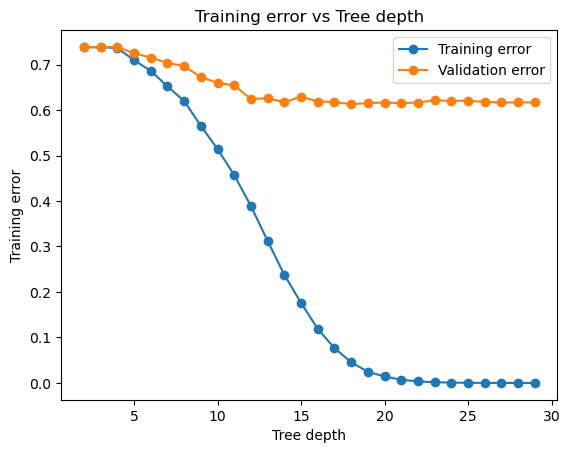

In [33]:
plt.plot(depths, train_errors, marker='o', label='Training error')
plt.plot(depths, val_errors, marker='o', label='Validation error')
plt.xlabel('Tree depth')       
plt.ylabel('Training error')   
plt.title('Training error vs Tree depth')
plt.legend()
plt.show()

In [35]:
#tree = result.best_estimator_.named_steps['model']
tree = best_tree 
feature_names = X_final.columns.tolist() 
print(feature_names)

print(export_text(tree, feature_names=feature_names))

['swear_IT', 'swear_EN', 'year', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'popularity', 'duration_sec', 'swear_ratio', 'aggressiveness', 'relative_popularity', 'song_age', 'region_references_Campania', 'region_references_Center', 'region_references_Lazio', 'region_references_Lombardia', 'region_references_North', 'release_season_Fall', 'release_season_Spring', 'release_season_Summer', 'release_season_Winter', 'explicit', 'has_collaboration']
|--- region_references_Campania <= 0.50
|   |--- region_references_Lazio <= 0.50
|   |   |--- song_age <= 0.50
|   |   |   |--- relative_popularity <= 1.10
|   |   |   |   |--- popularity <= -0.38
|   |   |   |   |   |--- relative_popularity <= -0.11
|   |   |   |   |   |   |--- char_per_tok <= -0.78
|   |   |   |   |   |   |   |--- centroid <= -0.56
|   |   |   |   |   |   |   |   |--- release_season_Spring

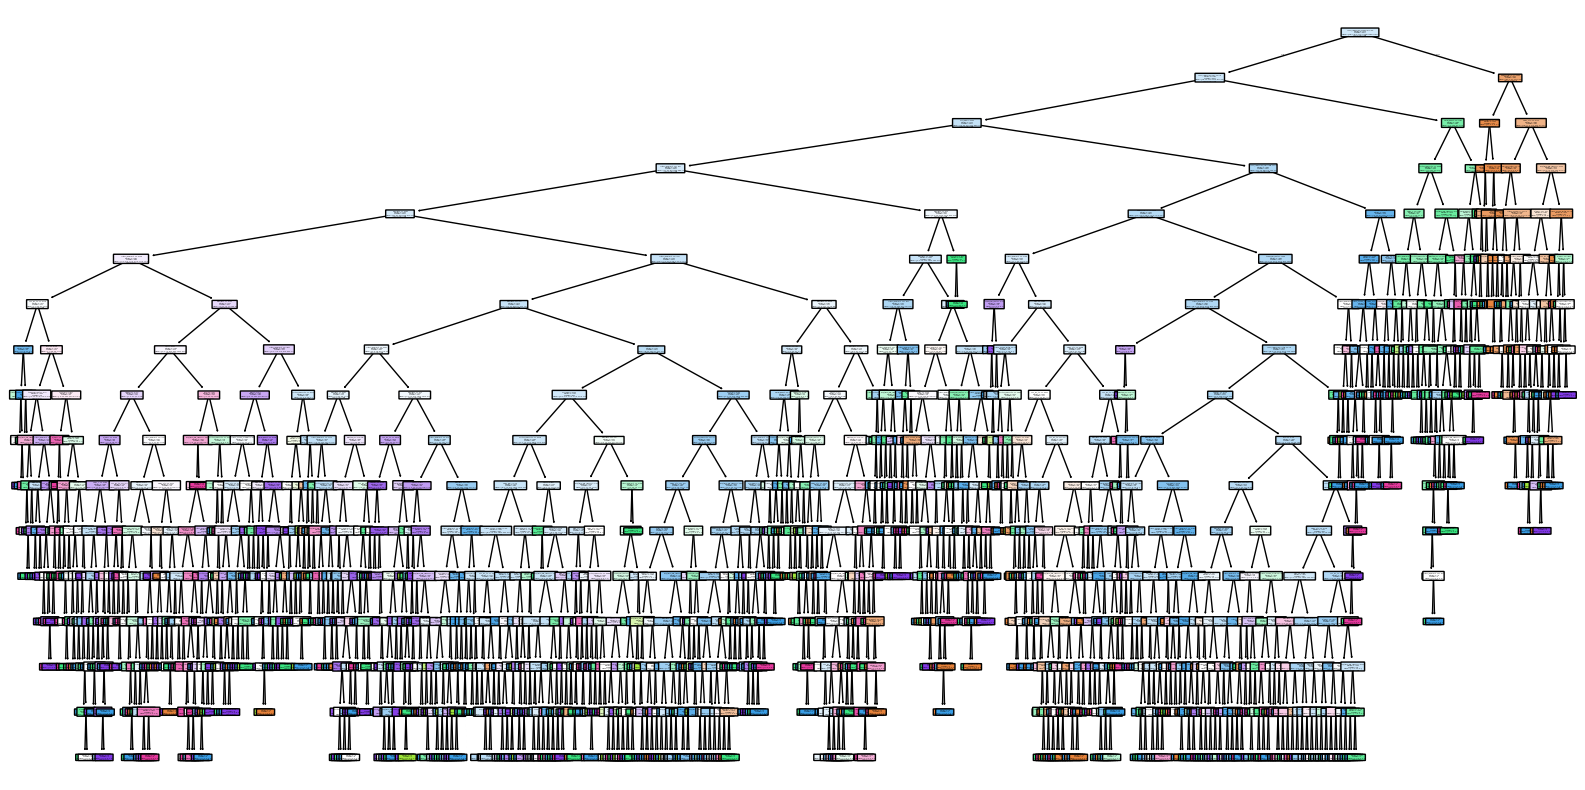

In [36]:
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=le.classes_,   
    filled=True,
    rounded=True
)
plt.show()

In [37]:
importances = pd.Series(tree.feature_importances_, index=feature_names)
importances.sort_values(ascending=False)

popularity                     0.114340
relative_popularity            0.103368
region_references_Campania     0.067365
avg_token_per_clause           0.042741
spectral_complexity            0.041963
char_per_tok                   0.038421
song_age                       0.038321
lexical_density                0.037698
loudness                       0.037249
tokens_per_sent                0.037103
swear_ratio                    0.037044
pitch                          0.036760
n_tokens                       0.036101
centroid                       0.033201
flux                           0.032375
bpm                            0.031563
flatness                       0.029320
aggressiveness                 0.029238
duration_sec                   0.027647
region_references_Lazio        0.026159
rolloff                        0.025568
year                           0.018507
explicit                       0.013139
swear_IT                       0.012825
release_season_Winter          0.008923


Training and evaluating Complex Models

In [39]:
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from interpret.glassbox import ExplainableBoostingClassifier

# Defining the complex models and their hyperparameter grids
pipe = Pipeline([('model',lgb.LGBMClassifier())])

grids = [
    {
        'model':[lgb.LGBMClassifier(objective='multiclass',n_jobs=2,random_state=seed,verbose=-1)],
        'model__num_leaves': [80],
        'model__max_depth': [-1],
        'model__learning_rate': [0.1],
        'model__n_estimators': [1200],
        'model__min_child_samples': [7],
        'model__subsample': [0.7],
        'model__min_gain_to_split':[0.0],
        'model__colsample_bytree':[0.9]
    },
    {
        'model':[SVC(random_state=seed)],
        'model__kernel': ['rbf'],
        'model__degree':[3],
        'model__decision_function_shape':['ovo'],
        'model__C': [10]      
    },
    {
        'model':[RandomForestClassifier(random_state=seed, n_jobs=2)],
        'model__n_estimators': [400],
        'model__criterion': ['entropy'],
        'model__max_depth': [10],          
        'model__min_samples_split': [2],         
        'model__min_samples_leaf': [5],           
        'model__max_features': ['sqrt'],        
        'model__class_weight': ['balanced'],
        'model__bootstrap':[True]  
    },
    {
        'model': [ExplainableBoostingClassifier(random_state=seed,n_jobs=2, feature_names=feature_names)],
        'model__learning_rate': [0.1],
        'model__max_bins': [128],
        'model__max_leaves': [3,7],
        'model__min_samples_leaf': [5],
        'model__interactions': [10]
    }

]

In [40]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=grids,
    cv = stratKFold,
    n_jobs=4,
    return_train_score = True,
    scoring = ['balanced_accuracy','accuracy','f1_weighted'],
    refit='balanced_accuracy',
    verbose=3 
)

result = grid.fit(X_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For mult

[CV 3/5] END model=LGBMClassifier(n_jobs=2, objective='multiclass', random_state=42, verbose=-1), model__colsample_bytree=0.9, model__learning_rate=0.1, model__max_depth=-1, model__min_child_samples=7, model__min_gain_to_split=0.0, model__n_estimators=1200, model__num_leaves=80, model__subsample=0.7; accuracy: (train=1.000, test=0.645) balanced_accuracy: (train=1.000, test=0.539) f1_weighted: (train=1.000, test=0.637) total time=  41.0s
[CV 1/5] END model=SVC(random_state=42), model__C=10, model__decision_function_shape=ovo, model__degree=3, model__kernel=rbf; accuracy: (train=0.951, test=0.551) balanced_accuracy: (train=0.948, test=0.466) f1_weighted: (train=0.951, test=0.542) total time=  13.2s
[CV 4/5] END model=SVC(random_state=42), model__C=10, model__decision_function_shape=ovo, model__degree=3, model__kernel=rbf; accuracy: (train=0.953, test=0.596) balanced_accuracy: (train=0.949, test=0.515) f1_weighted: (train=0.953, test=0.592) total time=  13.2s
[CV 4/5] END model=RandomFore

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


In [41]:
df = pd.DataFrame(result.cv_results_)
models = df['param_model'].unique()
cols =['params','mean_train_balanced_accuracy','mean_test_accuracy','mean_test_f1_weighted','mean_test_balanced_accuracy']
for model in models:
    mresults = df[df['param_model']==model]
    best_model = mresults.loc[mresults['mean_test_balanced_accuracy'].idxmax(), cols]
    print(best_model['params'])
    print(best_model)
df[cols]

{'model': LGBMClassifier(n_jobs=2, objective='multiclass', random_state=42, verbose=-1), 'model__colsample_bytree': 0.9, 'model__learning_rate': 0.1, 'model__max_depth': -1, 'model__min_child_samples': 7, 'model__min_gain_to_split': 0.0, 'model__n_estimators': 1200, 'model__num_leaves': 80, 'model__subsample': 0.7}
params                          {'model': LGBMClassifier(n_jobs=2, objective='...
mean_train_balanced_accuracy                                                  1.0
mean_test_accuracy                                                       0.650977
mean_test_f1_weighted                                                    0.641262
mean_test_balanced_accuracy                                              0.528187
Name: 0, dtype: object
{'model': SVC(random_state=42), 'model__C': 10, 'model__decision_function_shape': 'ovo', 'model__degree': 3, 'model__kernel': 'rbf'}
params                          {'model': SVC(random_state=42), 'model__C': 10...
mean_train_balanced_accuracy       

,params,mean_train_balanced_accuracy,mean_test_accuracy,mean_test_f1_weighted,mean_test_balanced_accuracy
0,"{'model': LGBMClassifier(n_jobs=2, objective='...",1.000000,0.650977,0.641262,0.528187
1,"{'model': SVC(random_state=42), 'model__C': 10...",0.949579,0.566166,0.559894,0.492587
2,"{'model': RandomForestClassifier(n_jobs=2, ran...",0.868161,0.484647,0.492811,0.506239
3,{'model': ExplainableBoostingClassifier(featur...,0.804335,0.647391,0.642089,0.578906
4,{'model': ExplainableBoostingClassifier(featur...,0.839809,0.628590,0.621220,0.541053


In [42]:
print(f"Result: {result.best_score_}, best hyperparameters: {result.best_params_}")

Result: 0.5789056534521447, best hyperparameters: {'model': ExplainableBoostingClassifier(feature_names=['swear_IT', 'swear_EN', 'year',
                                             'n_tokens', 'tokens_per_sent',
                                             'char_per_tok', 'lexical_density',
                                             'avg_token_per_clause', 'bpm',
                                             'centroid', 'rolloff', 'flux',
                                             'flatness', 'spectral_complexity',
                                             'pitch', 'loudness', 'popularity',
                                             'duration_sec', 'swear_ratio',
                                             'aggressiveness',
                                             'relative_popularity', 'song_age',
                                             'region_references_Campania',
                                             'region_references_Center',
                            

Final model and test set score

In [43]:
from sklearn.metrics import balanced_accuracy_score

final_model = result.best_estimator_

y_pred = final_model.predict(X_test)
print(f"Final test score: {balanced_accuracy_score(y_test,y_pred)}")

Final test score: 0.5969922397997026


In [44]:
from sklearn.metrics import accuracy_score, f1_score
print(f"Final accuracy test score: {accuracy_score(y_test,y_pred)}")
print(f"Final F1 test score: {f1_score(y_test,y_pred,average='weighted')}")

Final accuracy test score: 0.6521239954075775
Final F1 test score: 0.6491436692515018


In [45]:
from interpret import show
ebm = final_model['model']
global_exp = ebm.explain_global()
show(global_exp)


/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term year & popularity from explanation since we can't graph multinomial interactions.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term year & relative_popularity from explanation since we can't graph multinomial interactions.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term year & release_season_Fall from explanation since we can't graph multinomial interactions.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term year & explicit from explanation since we can't graph multinomial interactions.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term spec

<!-- http://127.0.0.1:7001/134577704672208/ -->

In [173]:
ebm_local = ebm.explain_local(X_test, y_test)
show(ebm_local)

<!-- http://127.0.0.1:7001/124166209083664/ -->

In [178]:
f = global_exp.data(12)
f.keys()
f['scores']

array([[-1.94534901e-01,  4.46403996e-01, -2.11447499e-01,
         1.52678340e-01, -3.38203401e-03,  4.00014700e-02],
       [-1.68513625e-01,  4.36735449e-01, -1.66621529e-01,
         1.14438076e-01,  7.76214456e-03,  4.08812884e-02],
       [-1.28897903e-01,  3.77445383e-01, -1.19093628e-01,
         4.67869161e-02,  2.48908877e-02,  8.18658430e-02],
       [-4.58183837e-02,  2.36165797e-01, -1.06317898e-01,
         8.61250895e-03, -2.88650685e-03,  1.41312133e-01],
       [ 7.85000169e-02,  2.54989296e-01, -6.66715955e-02,
        -7.71199703e-02, -1.66848595e-03,  1.97323726e-01],
       [ 1.30180345e-01,  2.50145452e-01, -3.33220256e-02,
        -1.05582112e-01, -5.41922041e-03,  1.93306052e-01],
       [ 1.61697491e-01,  2.15103485e-01,  5.31461122e-04,
        -1.00796627e-01, -2.47891761e-04,  1.29020031e-01],
       [ 1.66480666e-01,  1.99006091e-01,  1.86815386e-02,
        -1.07414131e-01,  3.90223214e-03,  1.13833316e-01],
       [ 1.31742146e-01,  5.64487321e-02,  2.427

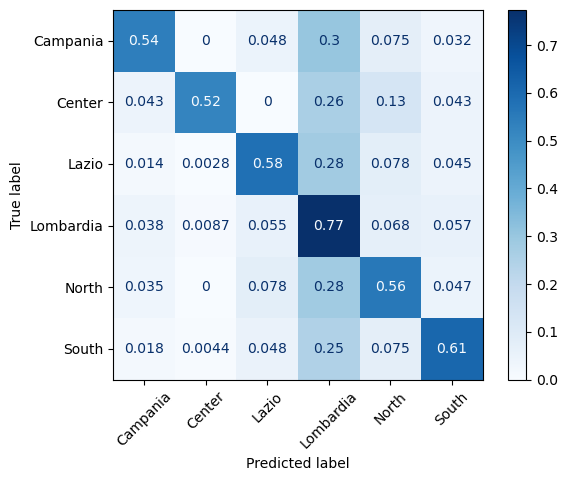

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
class_names = le.classes_  
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=45)